In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df_eth = pd.read_csv('../data/processed/ethiopia_new.csv')
df_imp = pd.read_csv('../data/processed/impact_new.csv')

df_eth.head()
df_imp.head()


,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


record_type
event          13
observation    36
target          3
dtype: int64
pillar
ACCESS           19
AFFORDABILITY     1
GENDER            5
USAGE            14
dtype: int64
source_type
calculated     2
news           2
operator      15
policy         3
regulator      7
research       4
survey        10
dtype: int64


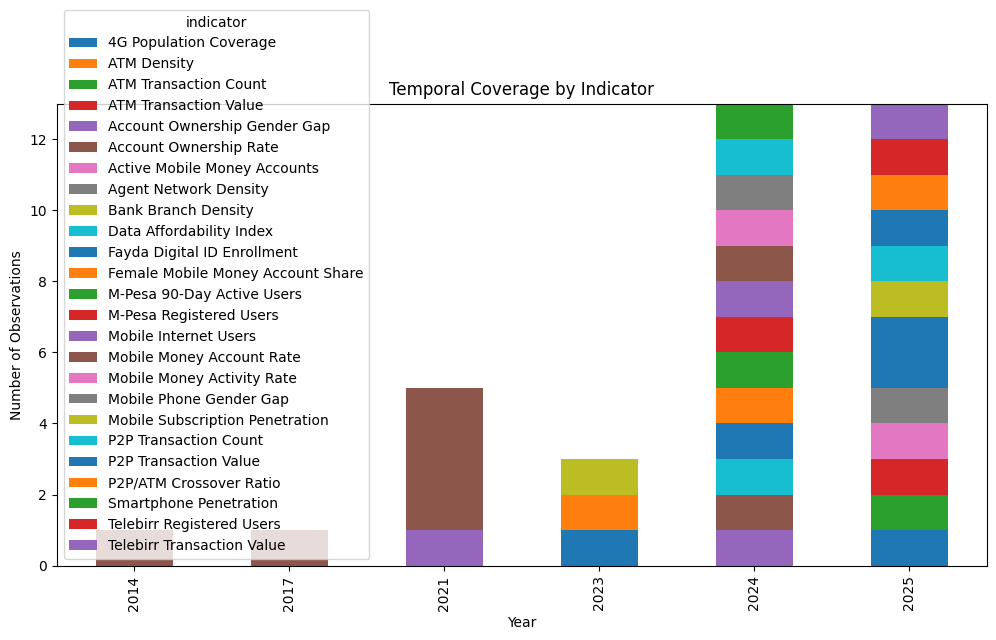

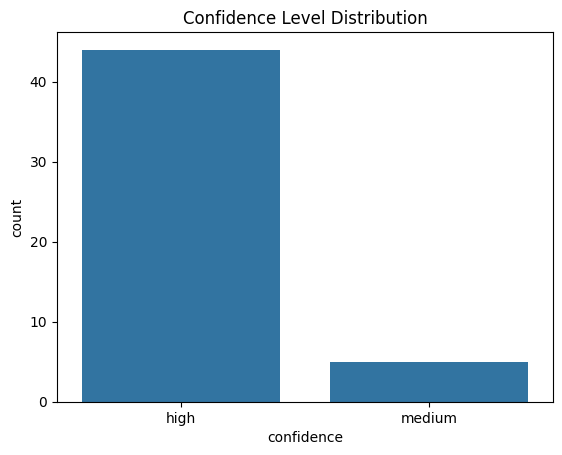

indicator
ATM Density                          1
ATM Transaction Count                1
ATM Transaction Value                1
Agent Network Density                1
Active Mobile Money Accounts         1
Female Mobile Money Account Share    1
Data Affordability Index             1
Bank Branch Density                  1
Mobile Internet Users                1
M-Pesa Registered Users              1
M-Pesa 90-Day Active Users           1
Smartphone Penetration               1
P2P Transaction Value                1
Mobile Subscription Penetration      1
Mobile Phone Gender Gap              1
Mobile Money Activity Rate           1
Telebirr Registered Users            1
P2P/ATM Crossover Ratio              1
Telebirr Transaction Value           1
P2P Transaction Count                2
4G Population Coverage               2
Mobile Money Account Rate            2
Account Ownership Gender Gap         2
Fayda Digital ID Enrollment          3
Account Ownership Rate               6
dtype: int64


In [2]:
print(df_eth.groupby('record_type').size())
print(df_eth.groupby('pillar').size())
print(df_eth.groupby('source_type').size())

df_eth['year'] = pd.to_datetime(df_eth['observation_date']).dt.year
temporal = df_eth[df_eth['record_type']=='observation'].groupby(['year','indicator']).size().unstack(fill_value=0)
temporal.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Temporal Coverage by Indicator")
plt.xlabel("Year")
plt.ylabel("Number of Observations")
plt.show()

sns.countplot(data=df_eth, x='confidence')
plt.title("Confidence Level Distribution")
plt.show()

sparse = df_eth[df_eth['record_type']=='observation'].groupby('indicator').size()
print(sparse.sort_values())


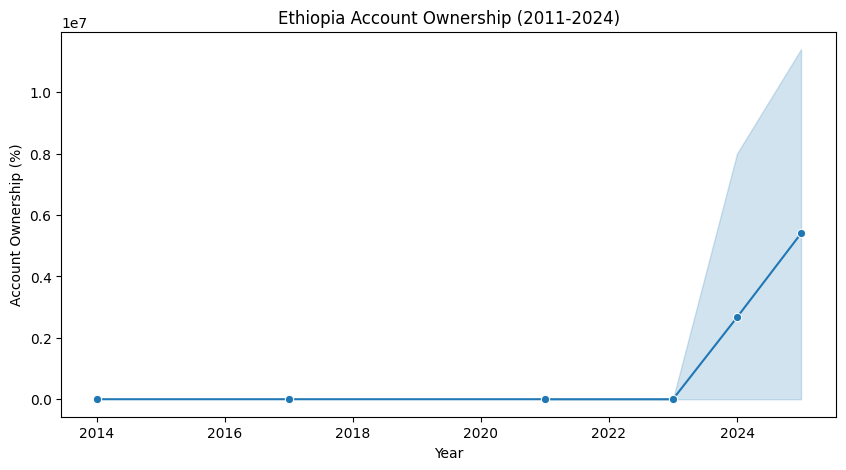

    year  value_numeric    growth_pp
0   2014          22.00          NaN
1   2017          35.00        13.00
2   2021          46.00        11.00
3   2021          56.00        10.00
4   2021          36.00       -20.00
6   2021           4.70       -31.30
8   2023          37.50        32.80
44  2023          10.23       -27.27
43  2023          14.50         4.27
11  2024     8000000.00   7999985.50
7   2024           9.45  -7999990.55
5   2024          49.00        39.55
12  2025    12000000.00  11999951.00
13  2025    15000000.00   3000000.00
9   2025          70.80 -14999929.20
45  2025           0.41       -70.39
10  2025          61.40        60.99


In [3]:
access_obs = df_eth[(df_eth['record_type']=='observation') & (df_eth['pillar']=='ACCESS')]
access_obs_sorted = access_obs.sort_values('observation_date')

plt.figure(figsize=(10,5))
sns.lineplot(data=access_obs_sorted, x='year', y='value_numeric', marker='o')
plt.title("Ethiopia Account Ownership (2011-2024)")
plt.ylabel("Account Ownership (%)")
plt.xlabel("Year")
plt.show()

access_obs_sorted['growth_pp'] = access_obs_sorted['value_numeric'].diff()
print(access_obs_sorted[['year','value_numeric','growth_pp']])


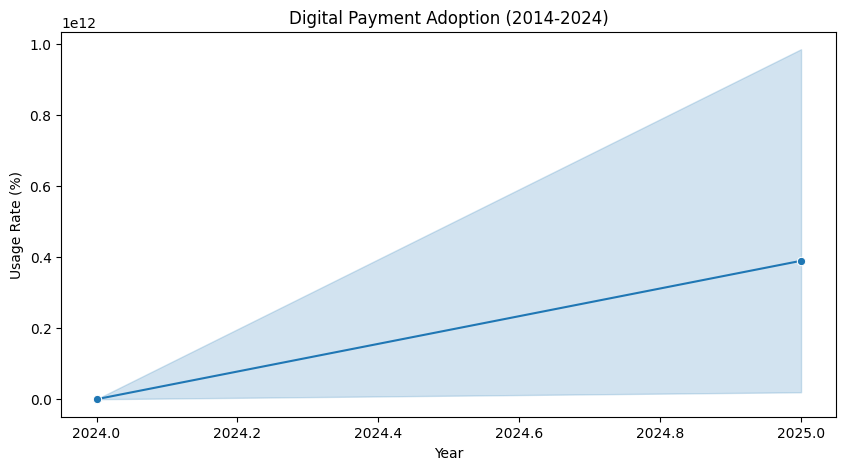

In [4]:
usage_obs = df_eth[(df_eth['record_type']=='observation') & (df_eth['pillar']=='USAGE')]
usage_obs_sorted = usage_obs.sort_values('observation_date')

plt.figure(figsize=(10,5))
sns.lineplot(data=usage_obs_sorted, x='year', y='value_numeric', marker='o')
plt.title("Digital Payment Adoption (2014-2024)")
plt.ylabel("Usage Rate (%)")
plt.xlabel("Year")
plt.show()


In [ ]:
access_df = (
    df_eth[
        (df_eth['record_type'] == 'observation') &
        (df_eth['pillar'] == 'ACCESS')
    ][['year', 'value_numeric']]
    .groupby('year', as_index=False)
    .mean()
    .rename(columns={'value_numeric': 'ACCESS'})
)

In [12]:
infra_indicators = [
    'Account Ownership Rate',
    'Mobile Money Account Rate',
    '4G Population Coverage',
    'Mobile Subscription Penetration',
    'Fayda Digital ID Enrollment',
    'P2P Transaction Count',
    'P2P Transaction Value',
    'ATM Transaction Count',
    'ATM Transaction Value',
    'P2P/ATM Crossover Ratio',
    'Telebirr Registered Users',
    'Telebirr Transaction Value',
    'M-Pesa Registered Users',
    'M-Pesa 90-Day Active Users',
    'Mobile Money Activity Rate',
    'Data Affordability Index',
    'Account Ownership Gender Gap',
    'Female Mobile Money Account Share',
    'Mobile Phone Gender Gap',
    'Bank Branch Density',
    'ATM Density',
    'Agent Network Density',
    'Active Mobile Money Accounts',
    'Smartphone Penetration'
]
infra = df_eth[
    (df_eth['record_type'] == 'observation') &
    (df_eth['indicator'].isin(infra_indicators))
][['year', 'indicator', 'value_numeric']]


infra_agg = (
    infra
    .groupby(['year', 'indicator'], as_index=False)
    .mean()
)

infra_corr = (
    infra_agg
    .pivot(index='year', columns='indicator', values='value_numeric')
    .join(access_df.set_index('year'))
)

infra_corr.corr()['ACCESS'].sort_values(ascending=False)


ACCESS                               1.000000
Mobile Money Account Rate            0.471404
4G Population Coverage               0.443579
Account Ownership Rate               0.245203
Fayda Digital ID Enrollment          0.223725
P2P Transaction Count                0.223725
Account Ownership Gender Gap        -0.471404
ATM Density                               NaN
ATM Transaction Count                     NaN
ATM Transaction Value                     NaN
Active Mobile Money Accounts              NaN
Agent Network Density                     NaN
Bank Branch Density                       NaN
Data Affordability Index                  NaN
Female Mobile Money Account Share         NaN
M-Pesa 90-Day Active Users                NaN
M-Pesa Registered Users                   NaN
Mobile Money Activity Rate                NaN
Mobile Phone Gender Gap                   NaN
Mobile Subscription Penetration           NaN
P2P Transaction Value                     NaN
P2P/ATM Crossover Ratio           

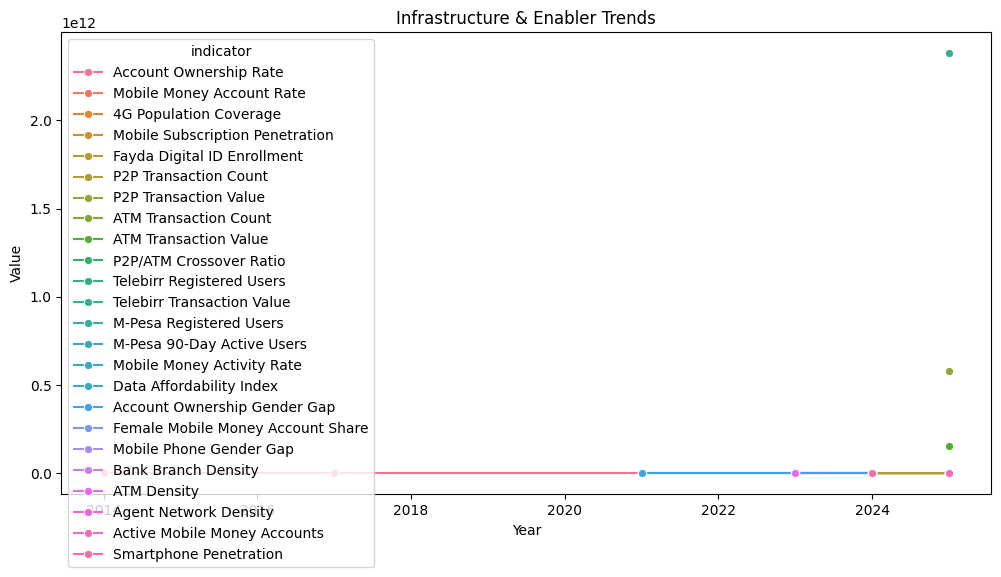

In [14]:
plt.figure(figsize=(12,6))
sns.lineplot(data=infra, x='year', y='value_numeric', hue='indicator', marker='o')
plt.title("Infrastructure & Enabler Trends")
plt.ylabel("Value")
plt.xlabel("Year")
plt.show()

infra_pivot = infra_agg.pivot(
    index='year',
    columns='indicator',
    values='value_numeric'
)

infra_corr = infra_pivot.join(
    access_df.set_index('year'),
    how='inner'
)

infra_corr.corr()['ACCESS'].sort_values(ascending=False)


access_df = access_obs_sorted[['year','value_numeric']].rename(columns={'value_numeric':'ACCESS'})


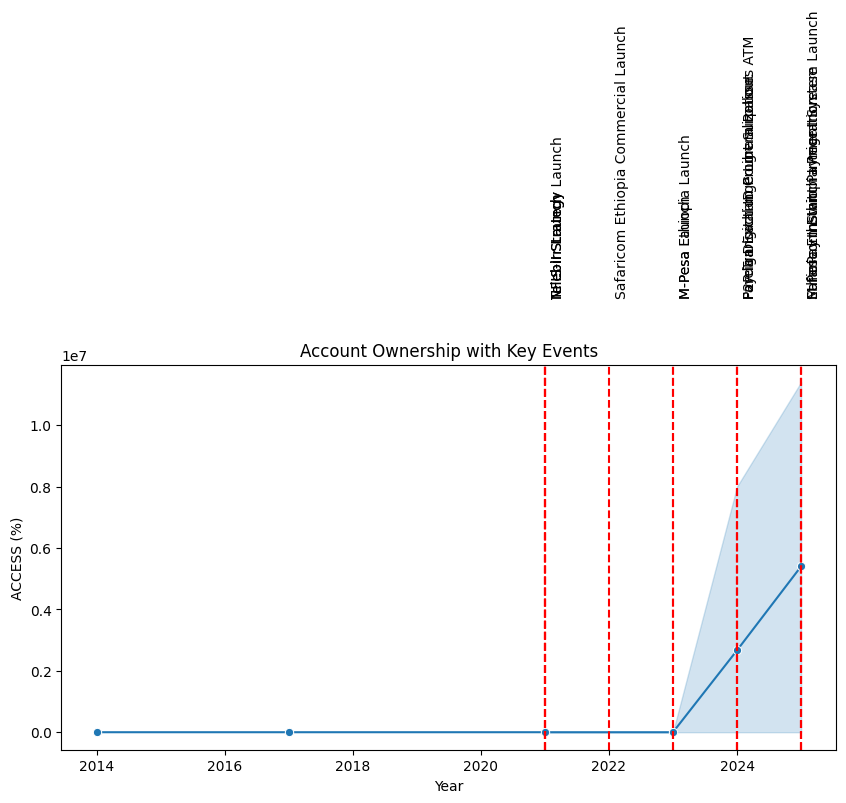

In [15]:
events = df_eth[df_eth['record_type']=='event']
imp_links = df_imp

access_plot = access_obs_sorted.copy()
plt.figure(figsize=(10,5))
sns.lineplot(data=access_plot, x='year', y='value_numeric', marker='o')
for _, evt in events.iterrows():
    plt.axvline(pd.to_datetime(evt['observation_date']).year, linestyle='--', color='red')
    plt.text(pd.to_datetime(evt['observation_date']).year+0.1, access_plot['value_numeric'].max()*0.95, evt['indicator'], rotation=90)
plt.title("Account Ownership with Key Events")
plt.ylabel("ACCESS (%)")
plt.xlabel("Year")
plt.show()


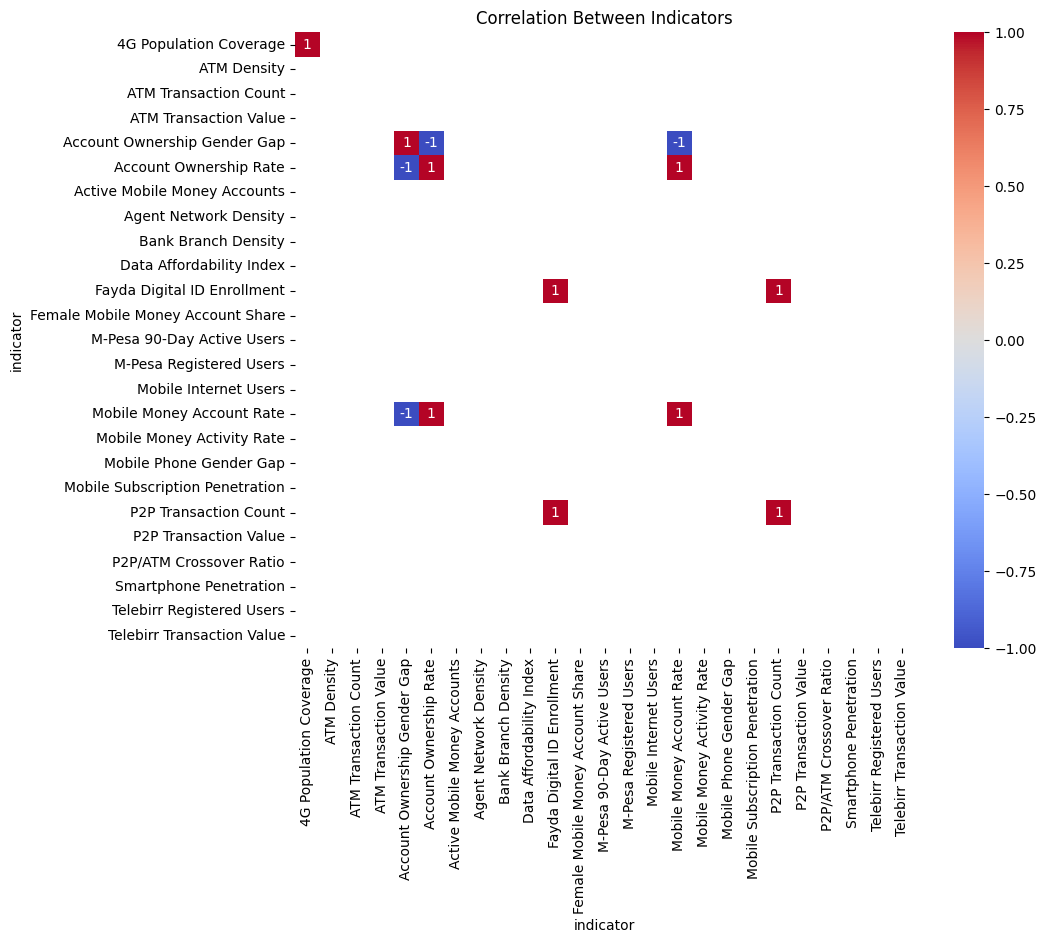

In [16]:
obs_pivot = (
    df_eth[df_eth['record_type'] == 'observation']
    .pivot_table(
        index='year',
        columns='indicator',
        values='value_numeric',
        aggfunc='mean'
    )
)

corr_matrix = obs_pivot.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Between Indicators")
plt.show()
